Mounted at /content/drive
Using dataset:
 Original : /content/drive/MyDrive/PaddyVarietyBD/PaddyOriginal.zip
 Augmented: /content/drive/MyDrive/PaddyVarietyBD/PaddyAugmented.zip

Extracting zips (this is done once per session)...

Classes found in extracted folder:
['BD70', 'Bd30', 'Bd33', 'Bd34', 'Bd49', 'Bd51', 'Bd52', 'Bd56', 'Bd57', 'Bd72', 'Bd75', 'Bd76', 'Bd79', 'Bd85', 'Bd87', 'Bd91', 'Bd93', 'Bd95', 'Binadhan07', 'Binadhan08', 'Binadhan10', 'Binadhan11', 'Binadhan12', 'Binadhan14', 'Binadhan16', 'Binadhan17', 'Binadhan19', 'Binadhan20', 'Binadhan21', 'Binadhan23', 'Binadhan24', 'Binadhan25', 'Binadhan26', 'Br22', 'Br23']
BD70: 400 train, 100 val
Bd30: 400 train, 100 val
Bd33: 400 train, 100 val
Bd34: 400 train, 100 val
Bd49: 400 train, 100 val
Bd51: 400 train, 100 val
Bd52: 400 train, 100 val
Bd56: 400 train, 100 val
Bd57: 400 train, 100 val
Bd72: 400 train, 100 val
Bd75: 400 train, 100 val
Bd76: 400 train, 100 val
Bd79: 400 train, 100 val
Bd85: 400 train, 100 val
Bd87: 400 tra

Training:   0%|          | 0/438 [00:00<?, ?it/s]

Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Train Acc = 0.250 | Val Acc = 0.346
Train Loss = 2.490 | Val Loss = 2.137

Epoch 2/5


Training:   0%|          | 0/438 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Train Acc = 0.487 | Val Acc = 0.536
Train Loss = 1.581 | Val Loss = 1.475

Epoch 5/5


Training:   0%|          | 0/438 [00:00<?, ?it/s]

Validating:   0%|          | 0/110 [00:00<?, ?it/s]

Train Acc = 0.519 | Val Acc = 0.491
Train Loss = 1.464 | Val Loss = 1.622


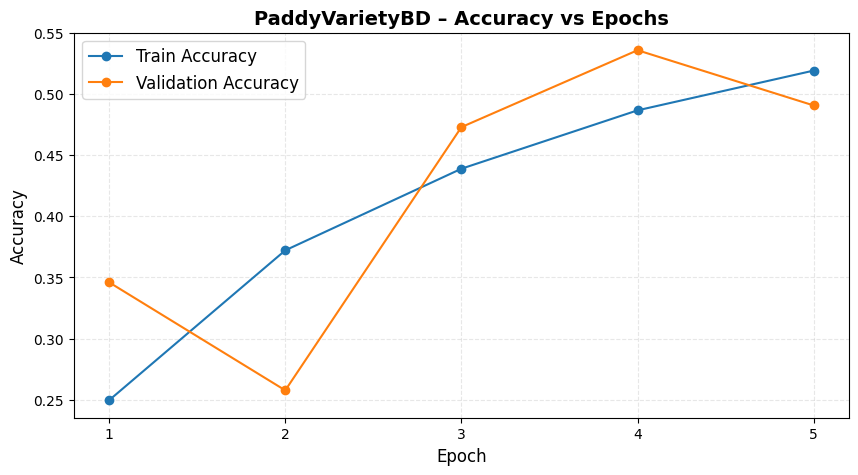

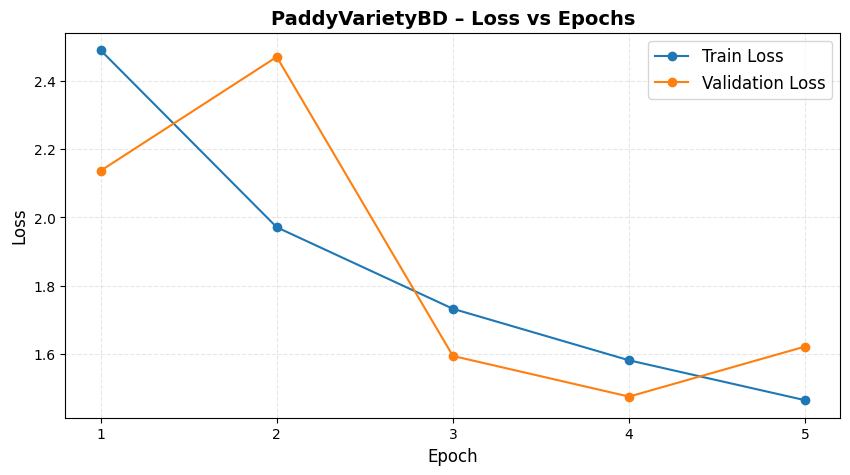

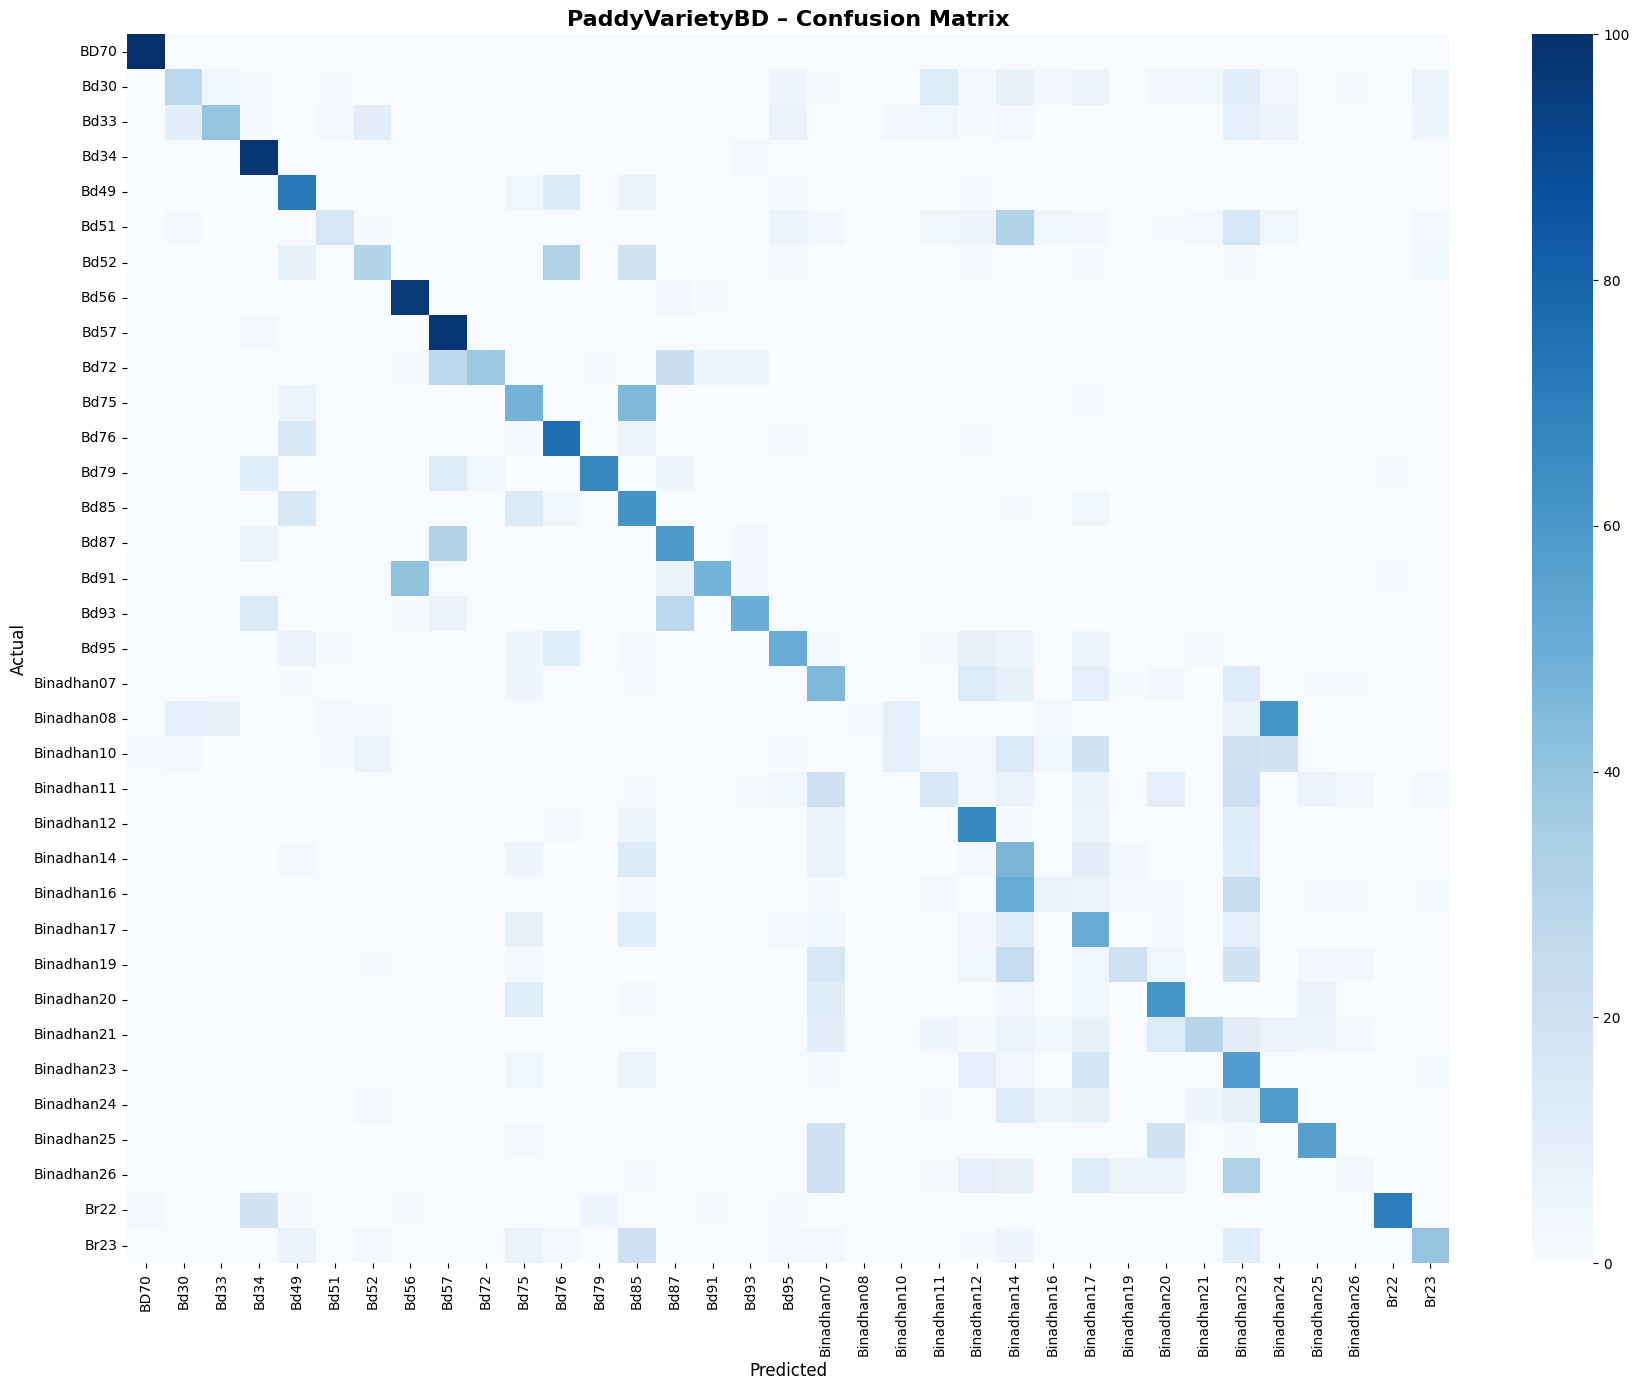

In [ ]:
import os, shutil, random
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from google.colab import drive

drive.mount("/content/drive")

ORIG_ZIP = "/content/drive/MyDrive/PaddyVarietyBD/PaddyOriginal.zip"
AUG_ZIP  = "/content/drive/MyDrive/PaddyVarietyBD/PaddyAugmented.zip"

print("Using dataset:")
print(" Original :", ORIG_ZIP)
print(" Augmented:", AUG_ZIP)

EXTRACT_DIR = "/content/paddy_extracted"
BASE_DIR    = "/content/paddy_project_small"
TRAIN_DIR   = os.path.join(BASE_DIR, "train")
VAL_DIR     = os.path.join(BASE_DIR, "val")

shutil.rmtree(EXTRACT_DIR, ignore_errors=True)
shutil.rmtree(BASE_DIR, ignore_errors=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

print("\nExtracting zips (this is done once per session)...")
!unzip -q "{ORIG_ZIP}" -d "{EXTRACT_DIR}"
!unzip -q "{AUG_ZIP}"  -d "{EXTRACT_DIR}"

print("\nClasses found in extracted folder:")
print(sorted(os.listdir(EXTRACT_DIR)))

EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

MAX_TRAIN_PER_CLASS = 400
MAX_VAL_PER_CLASS   = 100

random.seed(42)

total_train = 0
total_val   = 0

for cls in sorted(os.listdir(EXTRACT_DIR)):
    cls_src = os.path.join(EXTRACT_DIR, cls)
    if not os.path.isdir(cls_src):
        continue

    imgs = [f for f in os.listdir(cls_src)
            if f.lower().endswith(EXTS)]
    if len(imgs) == 0:
        continue

    random.shuffle(imgs)
    n_total = len(imgs)
    n_train = int(0.8 * n_total)

    train_imgs = imgs[:n_train]
    val_imgs   = imgs[n_train:]

    if MAX_TRAIN_PER_CLASS is not None:
        train_imgs = train_imgs[:MAX_TRAIN_PER_CLASS]
    if MAX_VAL_PER_CLASS is not None:
        val_imgs = val_imgs[:MAX_VAL_PER_CLASS]

    cls_train_dir = os.path.join(TRAIN_DIR, cls)
    cls_val_dir   = os.path.join(VAL_DIR, cls)
    os.makedirs(cls_train_dir, exist_ok=True)
    os.makedirs(cls_val_dir,   exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_src, img),
                    os.path.join(cls_train_dir, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_src, img),
                    os.path.join(cls_val_dir, img))

    total_train += len(train_imgs)
    total_val   += len(val_imgs)

    print(f"{cls}: {len(train_imgs)} train, {len(val_imgs)} val")

print(f"\nTotal train images: {total_train}")
print(f"Total val   images: {total_val}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)

train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

class_names = train_ds.classes
num_classes = len(class_names)

print("\nDetected Classes:", class_names)
print("Total classes:", num_classes)
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.block(x)

class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(
            in_ch, in_ch, 3, stride, 1, groups=in_ch, bias=False
        )
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
    def forward(self, x):
        return torch.relu(self.bn(self.pw(self.dw(x))))

class ResidualDownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.c1 = ConvBlock(in_ch, out_ch, stride=2)
        self.c2 = ConvBlock(out_ch, out_ch, stride=1)
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch)
        )
    def forward(self, x):
        return torch.relu(self.c2(self.c1(x)) + self.skip(x))

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 32),
            nn.MaxPool2d(2)
        )
        self.s1 = ResidualDownBlock(32, 64)
        self.s2 = nn.Sequential(
            DepthwiseSeparableBlock(64, 128, 2),
            ConvBlock(128, 128)
        )
        self.s3 = nn.Sequential(
            DepthwiseSeparableBlock(128, 256, 2),
            ConvBlock(256, 256)
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.s1(x)
        x = self.s2(x)
        x = self.s3(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

model = CNN(num_classes).to(device)
print("\nModel ready.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_acc_hist, val_acc_hist = [], []
train_loss_hist, val_loss_hist = [], []

def train_one_epoch():
    model.train()
    loss_sum, correct, total = 0.0, 0, 0

    for x, y in tqdm(train_loader, desc="Training"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total   += y.size(0)

    return loss_sum / len(train_loader), correct / total

def evaluate():
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_y, all_p = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validating"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

            all_y.extend(y.cpu().numpy())
            all_p.extend(preds.cpu().numpy())

    return loss_sum / len(val_loader), correct / total, all_y, all_p

EPOCHS = 5

best_y_true, best_y_pred = None, None

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    t_loss, t_acc = train_one_epoch()
    v_loss, v_acc, y_true, y_pred = evaluate()

    train_loss_hist.append(t_loss)
    val_loss_hist.append(v_loss)
    train_acc_hist.append(t_acc)
    val_acc_hist.append(v_acc)

    print(f"Train Acc = {t_acc:.3f} | Val Acc = {v_acc:.3f}")
    print(f"Train Loss = {t_loss:.3f} | Val Loss = {v_loss:.3f}")

    best_y_true, best_y_pred = y_true, y_pred

epochs = list(range(1, EPOCHS + 1))

plt.figure(figsize=(10,5))
plt.plot(epochs, train_acc_hist, label="Train Accuracy", marker='o')
plt.plot(epochs, val_acc_hist,   label="Validation Accuracy", marker='o')
plt.title("PaddyVarietyBD – Accuracy vs Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epochs, train_loss_hist, label="Train Loss", marker='o')
plt.plot(epochs, val_loss_hist,   label="Validation Loss", marker='o')
plt.title("PaddyVarietyBD – Loss vs Epochs", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

cm = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("PaddyVarietyBD – Confusion Matrix", fontsize=16, fontweight='bold')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
